<a href="https://colab.research.google.com/github/Tawanss/football/blob/main/%E0%B8%AB%E0%B8%A7%E0%B8%A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf

In [2]:
ประเภทฉลาก = []
วันที่ = []
เลขที่ออก =[]

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Create an empty list to store all data
data_list = []

# Loop through pages
for i in range(1, 22):
    r = requests.get(f'https://news.sanook.com/lotto/archive/page/{i}')
    s = BeautifulSoup(r.text, 'lxml')
    maindata = s.find_all('article', {'class': 'archive--lotto'})

    for c in maindata:
        # Extract date
        dates = c.find('h3', {'class': 'archive--lotto__head-lot'}).text

        # Extract result
        resultHEAD = c.find_all('ul', {'class': 'archive--lotto__result-list'})

        for rh in resultHEAD:
            first_prize = None
            last_two_digits = None

            for r in rh.find_all('li'):
                if 'รางวัลที่ 1' in r.text:
                    first_prize = r.find('strong', {'class': 'archive--lotto__result-number'}).text
                if 'เลขท้าย 2 ตัว' in r.text:
                    last_two_digits = r.find('strong', {'class': 'archive--lotto__result-number'}).text

            # Store data in dictionary format
            data_list.append({
                'วันที่': dates,
                'รางวัลที่ 1': first_prize,
                'เลขท้าย 2 ตัว': last_two_digits
            })

# Create DataFrame from list of dictionaries
df = pd.DataFrame(data_list)




In [6]:

# 1. อ่านไฟล์ CSV
# หมายเหตุ: ถ้าชื่อไฟล์ใน Colab ต่างจากนี้ ให้แก้ชื่อในวงเล็บครับ
file_path = '/content/drive/MyDrive/อุตุviz/File scrapping.xlsx'
df = pd.read_excel(file_path)



In [8]:
# 2. ลบ Row แรก (Index 0) และรีเซ็ต Index ใหม่
df = df.iloc[1:].reset_index(drop=True)

In [10]:
# ฟังก์ชันสำหรับแปลงวันที่ภาษาไทยเป็นสากล (YYYY-MM-DD)
def convert_thai_date(text):
    # Dictionary แปลงชื่อเดือนไทยเป็นตัวเลข
    thai_months = {
        'มกราคม': '01', 'กุมภาพันธ์': '02', 'มีนาคม': '03', 'เมษายน': '04',
        'พฤษภาคม': '05', 'มิถุนายน': '06', 'กรกฎาคม': '07', 'สิงหาคม': '08',
        'กันยายน': '09', 'ตุลาคม': '10', 'พฤศจิกายน': '11', 'ธันวาคม': '12'
    }

    # ใช้ Regex จับแพทเทิร์น: วันที่ (ตัวเลข) - เดือน (ภาษาไทย) - ปี (พ.ศ.)
    # รองรับทั้งแบบมีขีดคั่น (-) และแบบวรรค
    pattern = r'(\d{1,2})[- ]([ก-๙]+)[- ](\d{4})'
    match = re.search(pattern, str(text))

    if match:
        day, month_str, year_be = match.groups()

        # แปลงเดือนเป็นตัวเลข
        month_num = thai_months.get(month_str)

        # แปลงปี พ.ศ. เป็น ค.ศ. (ลบ 543)
        year_ad = int(year_be) - 543

        if month_num:
            # คืนค่าเป็นรูปแบบ YYYY-MM-DD
            return f"{year_ad}-{month_num}-{day.zfill(2)}"

    return None # กรณีหาไม่เจอ

In [11]:
# 3. ใช้ฟังก์ชันกับคอลัมน์ 'วันที่'
df['วันที่'] = df['วันที่'].apply(convert_thai_date)

# แปลงคอลัมน์ให้เป็นชนิด Datetime จริงๆ (เพื่อให้ sort หรือ plot กราฟได้ง่ายในอนาคต)
df['วันที่'] = pd.to_datetime(df['วันที่'])

# แสดงผลลัพธ์ 5 แถวแรก
print("ตัวอย่างข้อมูลที่คลีนแล้ว:")
print(df.head())

ตัวอย่างข้อมูลที่คลีนแล้ว:
      วันที่ รางวัลที่ 1 เลขท้าย 2 ตัว
0 2024-06-16      518504            31
1 2024-06-01      530593            42
2 2024-05-16      205690            60
3 2024-05-02      980116            17
4 2024-04-16      943598            79


In [12]:
df

,วันที่,รางวัลที่ 1,เลขท้าย 2 ตัว
0,2024-06-16,518504,31
1,2024-06-01,530593,42
2,2024-05-16,205690,60
3,2024-05-02,980116,17
4,2024-04-16,943598,79
...,...,...,...
412,2007-03-01,742425,61
413,2007-02-16,277859,95
414,2007-02-01,769925,56
415,2007-01-16,838739,54


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   วันที่         416 non-null    datetime64[ns]
 1   รางวัลที่ 1    417 non-null    object        
 2   เลขท้าย 2 ตัว  417 non-null    object        
dtypes: datetime64[ns](1), object(2)
memory usage: 9.9+ KB


In [26]:
# หาแถวที่คอลัมน์ 'วันที่' เป็นค่าว่าง (Null/NaT)
null_date_row = df[df['วันที่'].isnull()]


null_date_row

,วันที่,รางวัลที่ 1,เลขท้าย 2 ตัว
355,NaT,154986,92


In [27]:

df['เลขท้าย 2 ตัว'] = df['เลขท้าย 2 ตัว'].astype(str)

In [28]:
top_2_digits = df['เลขท้าย 2 ตัว'].value_counts()

In [49]:
top_2_digits

,count
เลขท้าย 2 ตัว,
79,11
85,9
14,8
92,8
98,8
...,...
84,1
04,1
74,1


/tmp/ipython-input-2327103103.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_2_digits.index, y=top_2_digits.values, palette='viridis')
/tmp/ipython-input-2327103103.py:10: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2327103103.py:10: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2327103103.py:10: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2327103103.py:10: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2327103103.py:10: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sa

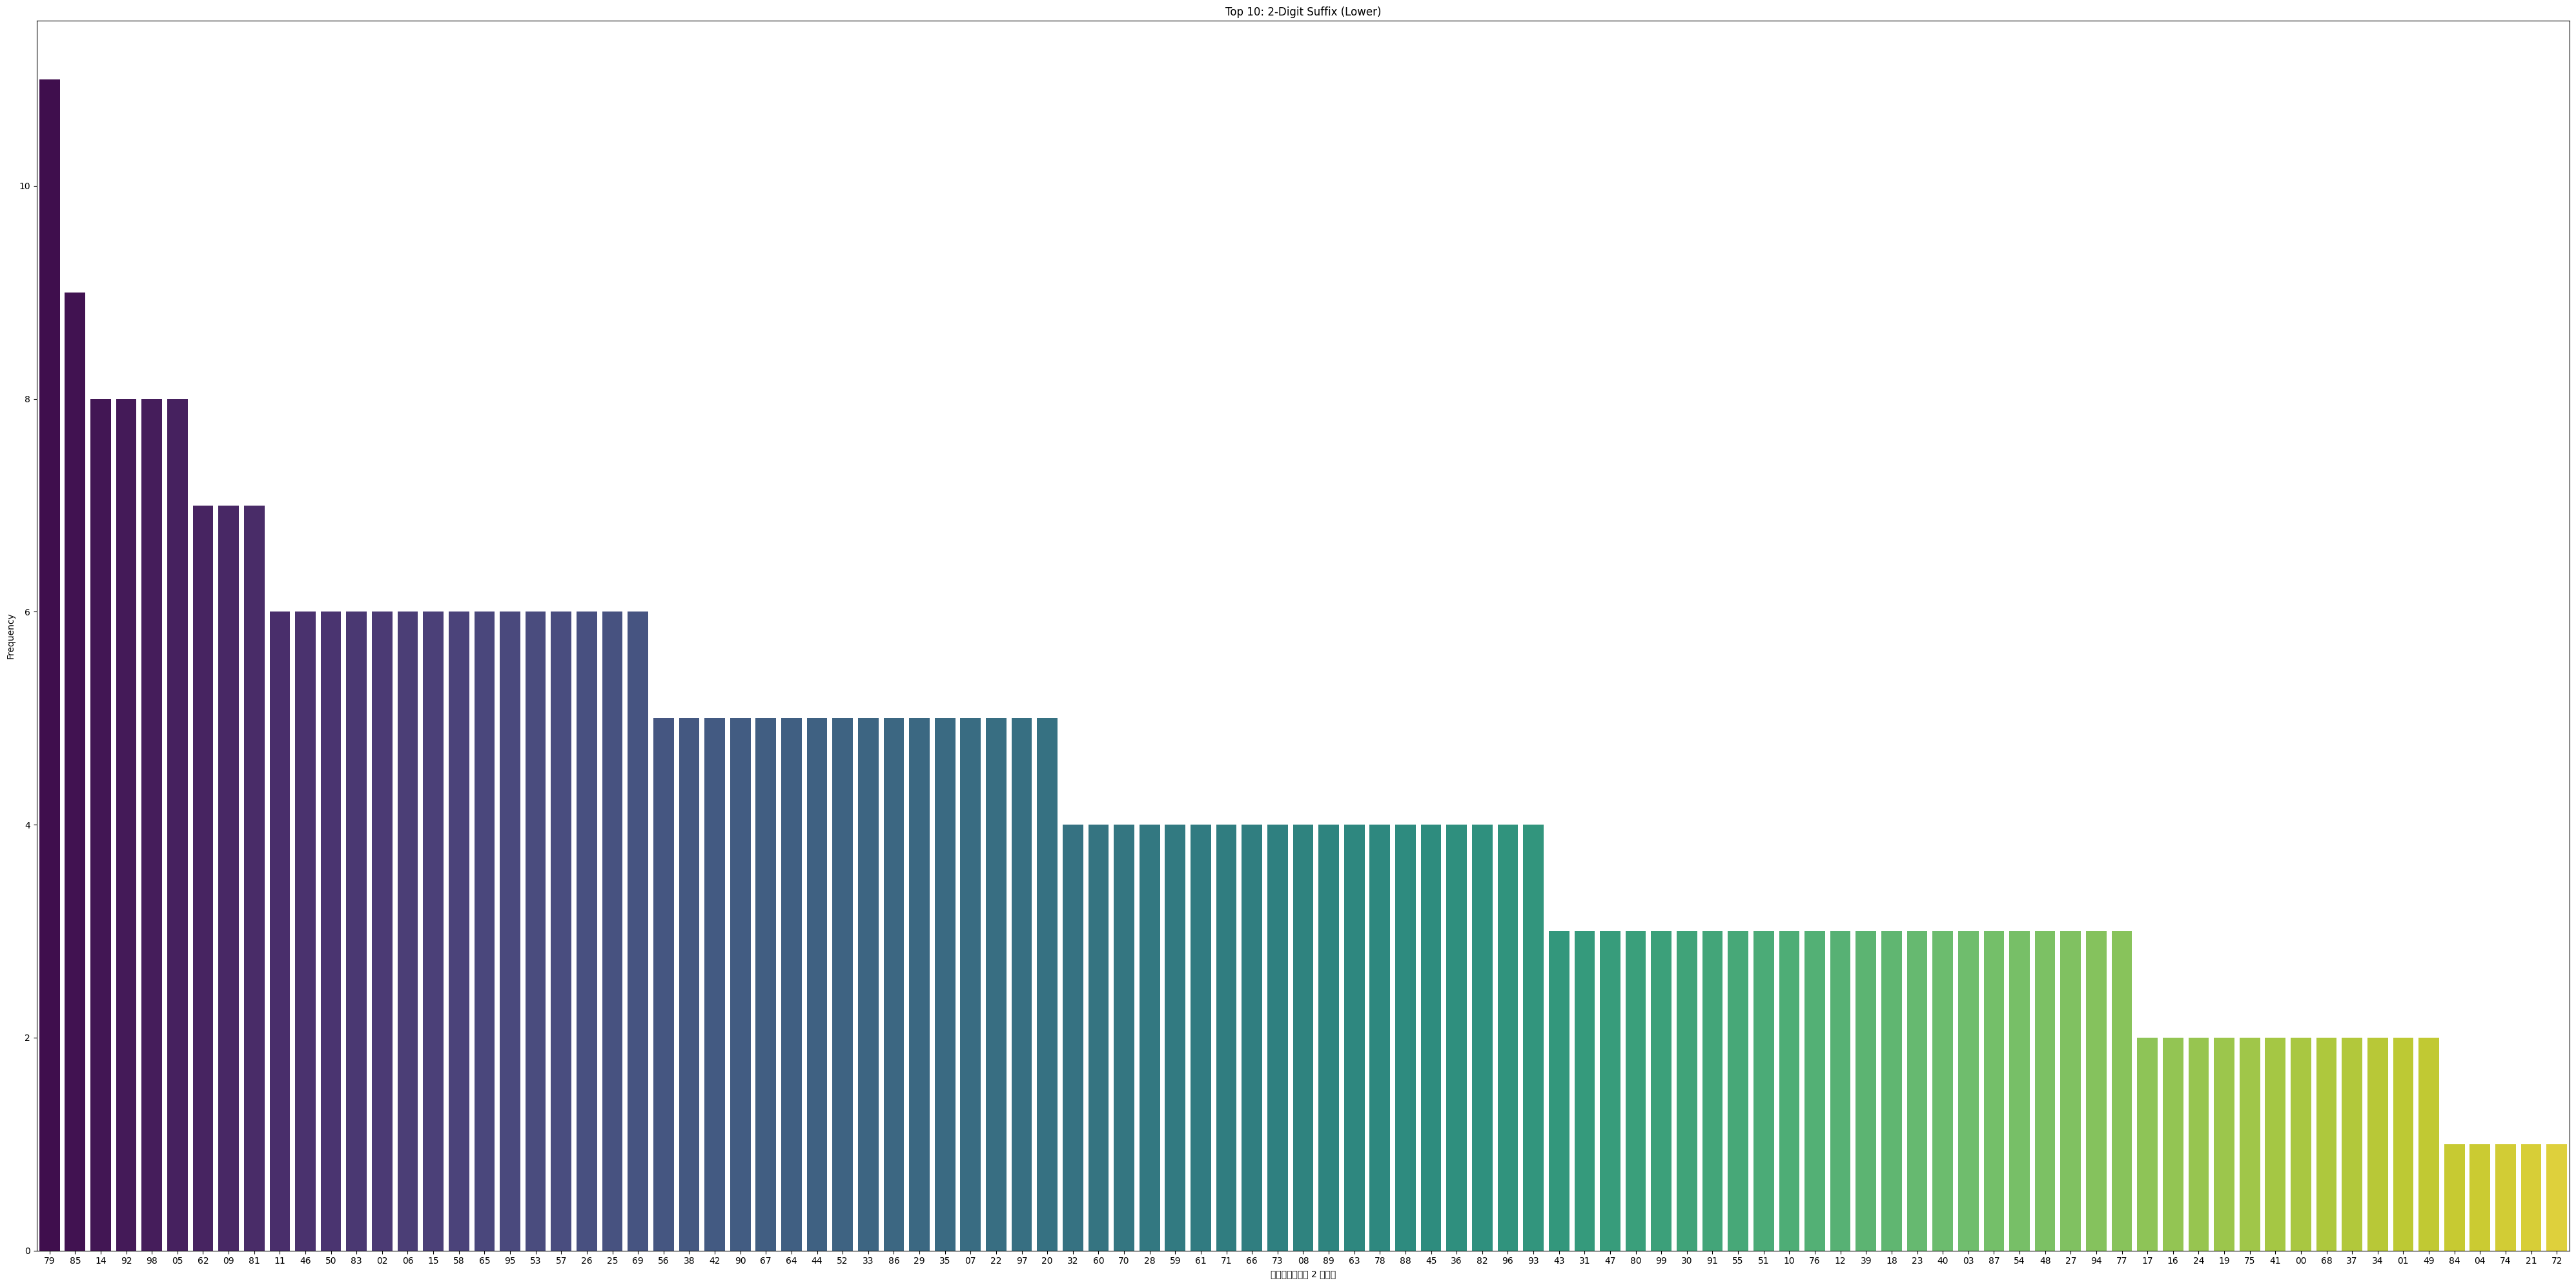

In [39]:
# --- 4. สร้างกราฟแสดงผล (Visualization) ---
# ตั้งค่า Font ภาษาไทย (ใน Colab อาจแสดงเป็นสี่เหลี่ยมถ้าไม่มีฟอนต์ ให้ดูที่แพทเทิร์นกราฟแทน)
plt.figure(figsize=(40, 20))

# เลขท้าย 2 ตัว (ล่าง)
sns.barplot(x=top_2_digits.index, y=top_2_digits.values, palette='viridis')
plt.title('Top 10: 2-Digit Suffix (Lower)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io,

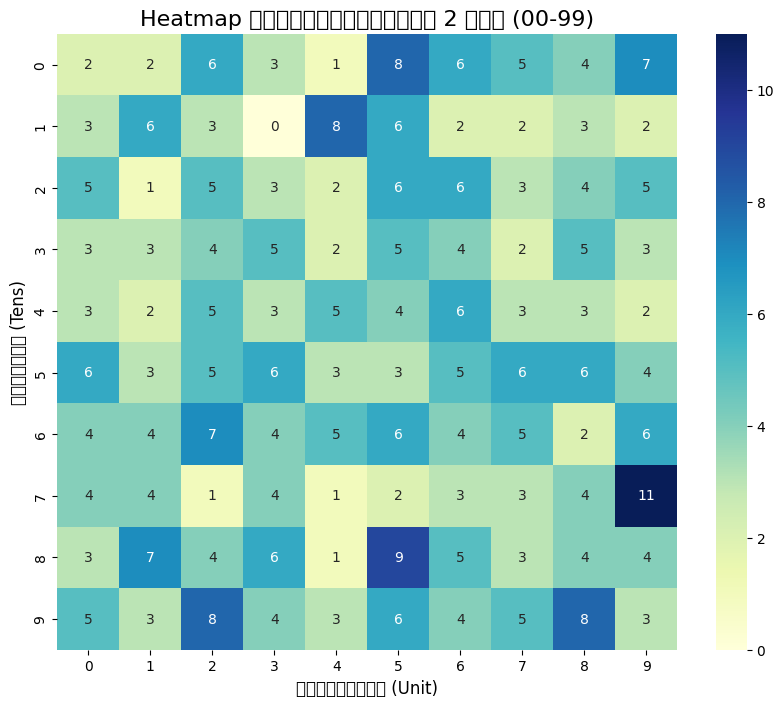

In [41]:

# --- 1. เตรียมข้อมูลสำหรับ Heatmap ---
# สร้างตารางเมทริกซ์ 10x10 (แถว 0-9, หลัก 0-9) เติมค่าเริ่มต้นเป็น 0
heatmap_data = np.zeros((10, 10))

# วนลูปนับจำนวนเลขที่ออก
for num in df['เลขท้าย 2 ตัว']:
    # แปลงเป็น string และเช็คความถูกต้อง
    num_str = str(num)
    if num_str.isdigit():
        tens = int(num_str[0])  # หลักสิบ
        units = int(num_str[1]) # หลักหน่วย
        heatmap_data[tens, units] += 1

# --- 2. วาดกราฟ Heatmap ---
plt.figure(figsize=(10, 8))

# สร้าง Heatmap
# annot=True : แสดงตัวเลขจำนวนครั้งในช่อง
# fmt='g' : แสดงเลขแบบจำนวนเต็ม (ไม่เอาทศนิยม)
# cmap='hot_r' : ใช้โทนสีร้อน (แดง=ออกเยอะ, ขาว/เหลือง=ออกน้อย) หรือลอง 'YlGnBu' ก็สวยครับ
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlGnBu',
            xticklabels=range(10), yticklabels=range(10))

plt.title('Heatmap ความถี่เลขท้าย 2 ตัว (00-99)', fontsize=16)
plt.xlabel('หลักหน่วย (Unit)', fontsize=12)
plt.ylabel('หลักสิบ (Tens)', fontsize=12)

plt.show()

กำลังจำลองสถานการณ์ 10,000 ครั้ง... กรุณารอสักครู่ ⏳
----------------------------------------
📊 ผลการวิเคราะห์ที่ระยะห่าง 455 งวด:
1. โอกาสที่จะเกิดเหตุการณ์แบบนี้มีเพียง: 0.98% (หายากมาก!)
   (แปลว่าใน 100 เหตุการณ์ จะเจอแบบนี้แค่ประมาณ 0 ครั้ง)
2. สถิติรอนานที่สุดที่เคยเจอในการจำลอง (Max Gap): 1167 งวด
----------------------------------------


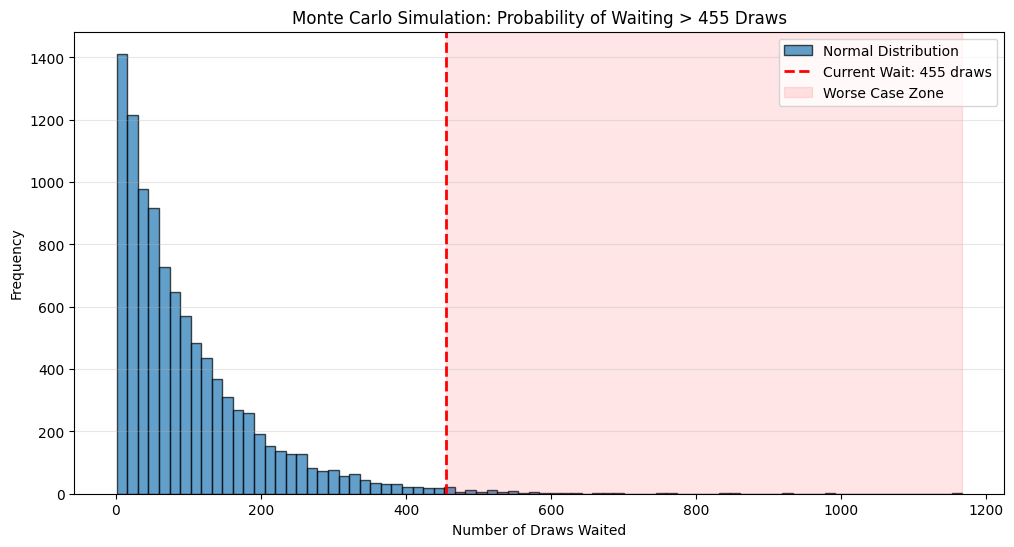

In [61]:

# --- Monte Carlo Simulation (ฉบับปรับปรุง) ---
# จำลองเหตุการณ์โลกคู่ขนาน 10,000 ใบ
simulations = 10000
waiting_times = []

print(f"กำลังจำลองสถานการณ์ {simulations:,} ครั้ง... กรุณารอสักครู่ ⏳")

# เริ่มจำลองการรอคอย
for _ in range(simulations):
    draws = 0
    while True:
        draws += 1
        # สุ่มเลข 0-99 (โอกาส 1%)
        result = np.random.randint(0, 100)
        if result == 13: # เจอเลข 13 แล้วหยุด
            waiting_times.append(draws)
            break

waiting_times = np.array(waiting_times)

# --- วิเคราะห์ผลลัพธ์ที่ gap = 455 ---
current_gap = 455 # <--- ปรับค่าตรงนี้ตามที่คุณต้องการ

# หาจำนวนครั้งที่ต้องรอ "นานกว่า" 455 งวด
worse_cases = waiting_times[waiting_times > current_gap]
prob_worse = len(worse_cases) / simulations * 100

print("-" * 40)
print(f"📊 ผลการวิเคราะห์ที่ระยะห่าง {current_gap} งวด:")
print(f"1. โอกาสที่จะเกิดเหตุการณ์แบบนี้มีเพียง: {prob_worse:.2f}% (หายากมาก!)")
print(f"   (แปลว่าใน 100 เหตุการณ์ จะเจอแบบนี้แค่ประมาณ {int(prob_worse)} ครั้ง)")
print(f"2. สถิติรอนานที่สุดที่เคยเจอในการจำลอง (Max Gap): {np.max(waiting_times)} งวด")
print("-" * 40)

# กราฟ Histogram
plt.figure(figsize=(12, 6))
# วาดฮิสโตแกรมสีฟ้า
plt.hist(waiting_times, bins=80, color='#1f77b4', edgecolor='black', alpha=0.7, label='Normal Distribution')

# วาดเส้นสีแดงตรงจุด 455 งวด
plt.axvline(x=current_gap, color='red', linestyle='--', linewidth=2, label=f'Current Wait: {current_gap} draws')

# วาดพื้นที่ส่วนหาง (Rare Event Area)
plt.axvspan(current_gap, np.max(waiting_times), color='red', alpha=0.1, label='Worse Case Zone')

plt.title(f'Monte Carlo Simulation: Probability of Waiting > {current_gap} Draws')
plt.xlabel('Number of Draws Waited')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

<Figure size 1000x600 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

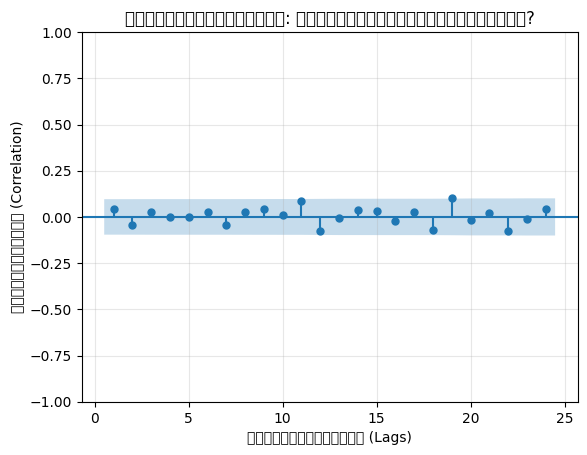

In [64]:
#1. เรียงข้อมูลตามวัน (อดีต -> ปัจจุบัน)
df_sorted = df.sort_values(by='วันที่', ascending=True)

# 2. แปลงข้อมูลเป็นตัวเลข (เพื่อคำนวณกราฟ)
series_data = df_sorted['เลขท้าย 2 ตัว'].astype(int)

# 3. วาดกราฟ ACF
# lags=24 คือขอดูย้อนหลังความสัมพันธ์ไป 24 งวด (ประมาณ 1 ปี)
plt.figure(figsize=(10, 6))
plot_acf(series_data, lags=24, alpha=0.05, title='เช็คความสัมพันธ์: อดีตส่งผลต่อปัจจุบันไหม?', zero=False) # zero=False เพื่อไม่ให้แสดงแท่งที่ 0

plt.xlabel('ย้อนหลังกี่งวด (Lags)')
plt.ylabel('ความสัมพันธ์ (Correlation)')
# สร้างแถบสีฟ้าจำลอง (ถ้าไม่ได้ใช้ statsmodels ตัวเต็ม) ปกติ plot_acf จะสร้างให้เอง
plt.grid(True, alpha=0.3)
plt.show()